In [23]:
import requests
import geopandas as gpd
import io
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
response = requests.get(url)
world = gpd.read_file(io.BytesIO(response.content))

print(world.shape)
world.head()

(177, 169)


,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ..."
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,None,None,None,None,None,None,None,None,None,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3..."
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,Unrecognized,Unrecognized,None,None,Unrecognized,None,None,None,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948..."
3,Admin-0 country,1,2,Canada,CAN,0,2,Sovereign country,1,Canada,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025..."
4,Admin-0 country,1,2,United States of America,US1,1,2,Country,1,United States of America,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312..."


In [26]:
print(world.columns.tolist())

['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3', 'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN', 'ADM0_A3', 'GEOU_DIF', 'GEOUNIT', 'GU_A3', 'SU_DIF', 'SUBUNIT', 'SU_A3', 'BRK_DIFF', 'NAME', 'NAME_LONG', 'BRK_A3', 'BRK_NAME', 'BRK_GROUP', 'ABBREV', 'POSTAL', 'FORMAL_EN', 'FORMAL_FR', 'NAME_CIAWF', 'NOTE_ADM0', 'NOTE_BRK', 'NAME_SORT', 'NAME_ALT', 'MAPCOLOR7', 'MAPCOLOR8', 'MAPCOLOR9', 'MAPCOLOR13', 'POP_EST', 'POP_RANK', 'POP_YEAR', 'GDP_MD', 'GDP_YEAR', 'ECONOMY', 'INCOME_GRP', 'FIPS_10', 'ISO_A2', 'ISO_A2_EH', 'ISO_A3', 'ISO_A3_EH', 'ISO_N3', 'ISO_N3_EH', 'UN_A3', 'WB_A2', 'WB_A3', 'WOE_ID', 'WOE_ID_EH', 'WOE_NOTE', 'ADM0_ISO', 'ADM0_DIFF', 'ADM0_TLC', 'ADM0_A3_US', 'ADM0_A3_FR', 'ADM0_A3_RU', 'ADM0_A3_ES', 'ADM0_A3_CN', 'ADM0_A3_TW', 'ADM0_A3_IN', 'ADM0_A3_NP', 'ADM0_A3_PK', 'ADM0_A3_DE', 'ADM0_A3_GB', 'ADM0_A3_BR', 'ADM0_A3_IL', 'ADM0_A3_PS', 'ADM0_A3_SA', 'ADM0_A3_EG', 'ADM0_A3_MA', 'ADM0_A3_PT', 'ADM0_A3_AR', 'ADM0_A3_JP', 'ADM0_A3_KO', 'ADM0_A3_VN', 'ADM0_A3_TR', 'AD

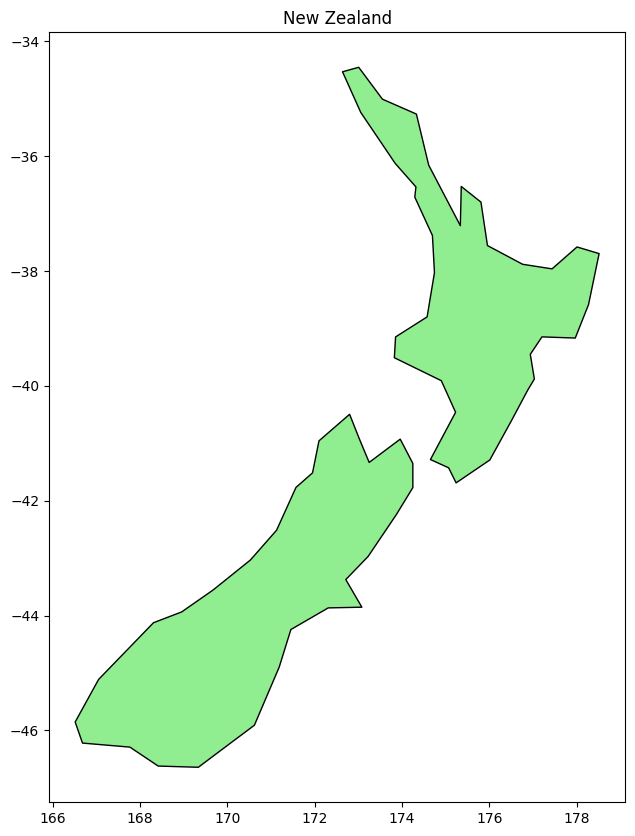

In [27]:
nz = world[world['NAME'] == 'New Zealand']
nz.plot(figsize=(8, 10), color='lightgreen', edgecolor='black')
plt.title('New Zealand')
plt.show()

In [31]:
import pandas as pd

df2 = pd.read_csv('../yield_df.csv')
df2 = df2.drop(columns=['Unnamed: 0'])

def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[column] >= Q1 - 1.5*IQR) & (df[column] <= Q3 + 1.5*IQR)]

df2_clean = remove_outliers(df2, 'pesticides_tonnes')
df2_clean = remove_outliers(df2_clean, 'hg/ha_yield')
print(df2_clean.shape)

(24785, 7)


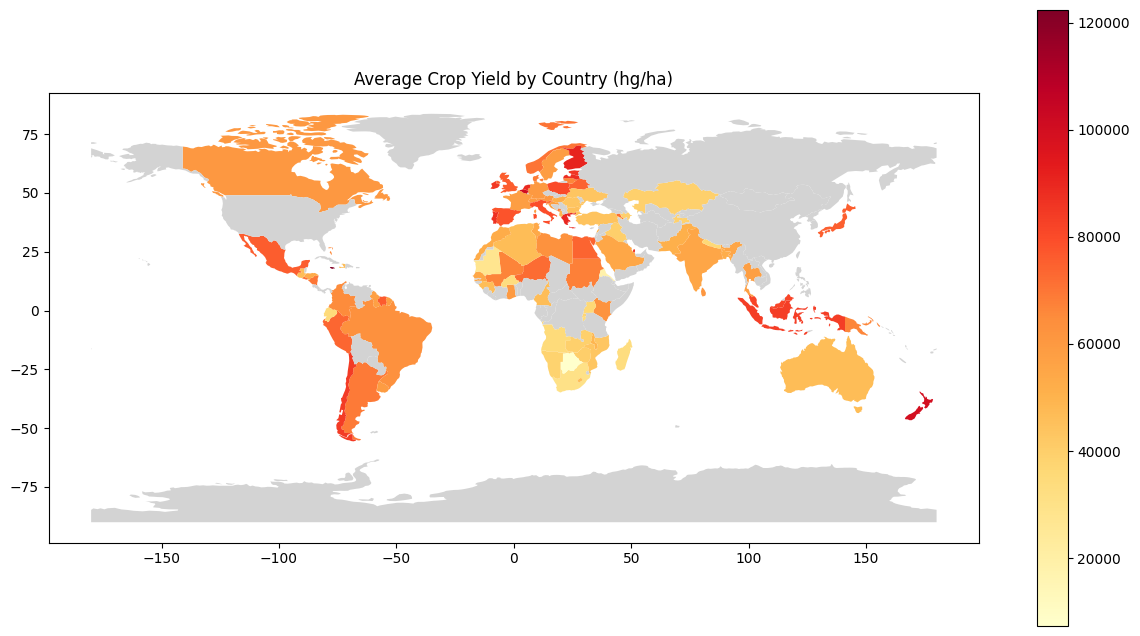

In [32]:
import pandas as pd

yield_geo = df2_clean.groupby('Area')['hg/ha_yield'].mean().reset_index()
yield_geo.columns = ['NAME', 'avg_yield']

world_yield = world.merge(yield_geo, on='NAME', how='left')

fig, ax = plt.subplots(figsize=(15, 8))
world_yield.plot(column='avg_yield',
                 ax=ax,
                 legend=True,
                 missing_kwds={'color': 'lightgrey'},
                 cmap='YlOrRd')
plt.title('Average Crop Yield by Country (hg/ha)')
plt.show()

In [33]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt

farm_points = pd.DataFrame({
    'farm': ['Christchurch Farm', 'Hawke\'s Bay Farm', 'Waikato Farm', 'Otago Farm'],
    'longitude': [172.6362, 176.8860, 175.3157, 170.4998],
    'latitude': [-43.5321, -39.6500, -37.7870, -45.8788],
    'avg_temp': [12.5, 14.2, 13.8, 10.1],
    'rainfall_mm': [640, 800, 1200, 550]
})

geometry = [Point(xy) for xy in zip(farm_points['longitude'], farm_points['latitude'])]
farms_gdf = gpd.GeoDataFrame(farm_points, geometry=geometry, crs='EPSG:4326')

print(farms_gdf)

                farm  longitude  latitude  avg_temp  rainfall_mm  \
0  Christchurch Farm   172.6362  -43.5321      12.5          640   
1   Hawke's Bay Farm   176.8860  -39.6500      14.2          800   
2       Waikato Farm   175.3157  -37.7870      13.8         1200   
3         Otago Farm   170.4998  -45.8788      10.1          550   

                    geometry  
0  POINT (172.6362 -43.5321)  
1     POINT (176.886 -39.65)  
2   POINT (175.3157 -37.787)  
3  POINT (170.4998 -45.8788)  


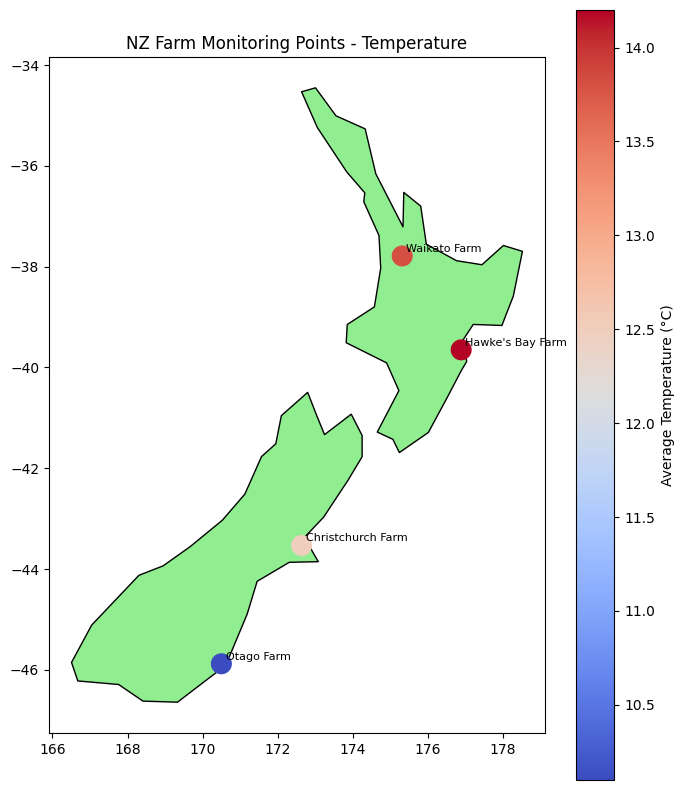

In [34]:
fig, ax = plt.subplots(figsize=(8, 10))

nz.plot(ax=ax, color='lightgreen', edgecolor='black')

farms_gdf.plot(ax=ax,
               column='avg_temp',
               cmap='coolwarm',
               markersize=200,
               legend=True,
               legend_kwds={'label': 'Average Temperature (°C)'})

for idx, row in farms_gdf.iterrows():
    ax.annotate(row['farm'],
                xy=(row['longitude'], row['latitude']),
                xytext=(3, 3),
                textcoords='offset points',
                fontsize=8)

plt.title('NZ Farm Monitoring Points - Temperature')
plt.show()